In [1]:
# In cell 1

import nltk
from nltk.corpus import treebank
import numpy as np
import re
from collections import Counter
# Removed unused imports: statistics, matplotlib.pyplot

# Download and load corpus
nltk.download('treebank', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

# --- Data Cleaning Function ---
# Regex to identify trace tokens and empty categories in Treebank
TRACE_TOKEN_PATTERN = re.compile(r'^\*.*\*$|^\*$|^\*-?\d+$|^0$')
def is_valid_token(word, pos_tag=None):
    """Checks if a token is valid (not a trace or -NONE- tag)."""
    if pos_tag == '-NONE-':
        return False
    if TRACE_TOKEN_PATTERN.match(word):
        return False
    return True

# --- Load and Clean Sentences ---
original_tagged_sentences = treebank.tagged_sents()
cleaned_tagged_sentences = []
for sentence in original_tagged_sentences:
    # Filter out invalid tokens from each sentence
    cleaned_tokens = [(word, pos) for word, pos in sentence if is_valid_token(word, pos)]

    if cleaned_tokens:
        cleaned_tagged_sentences.append(cleaned_tokens)

# Check if any sentences remain after cleaning
if not cleaned_tagged_sentences:
    raise ValueError("No valid sentences found after cleaning. Check the cleaning logic and corpus.")

# --- Prepare Data for Modeling ---
# We keep the variable name 'filtered_...' for consistency with subsequent cells
filtered_tagged_sentences = cleaned_tagged_sentences

# Create list of sentence strings (plain text) for BERT input
filtered_sentences_text = [" ".join([word for word, pos in sentence]) for sentence in filtered_tagged_sentences]

# --- Create Target Variable (Verb Presence) ---
# Define the set of Penn Treebank tags considered as verbs
VERB_TAGS = {'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ'}
y = []
for sentence in filtered_tagged_sentences:
    # Check if any token in the sentence has a verb tag
    has_verb = any(pos in VERB_TAGS for word, pos in sentence)
    y.append(1 if has_verb else 0) # 1 if verb present, 0 otherwise
y = np.array(y) 

# --- Gather Basic Statistics on the Final Dataset ---
final_total_sentences = len(filtered_tagged_sentences)
final_all_tokens = [word for sentence in filtered_tagged_sentences for word, pos in sentence]
final_total_tokens = len(final_all_tokens)
final_unique_tokens = set(final_all_tokens)
final_total_unique_tokens = len(final_unique_tokens)

# Verb presence statistics using the target variable 'y'
verb_counts = Counter(y)
sentences_with_verbs = verb_counts.get(1, 0) 
sentences_without_verbs = verb_counts.get(0, 0)

# --- Print Statistics ---
print(f"Original tagged sentences from Treebank: {len(original_tagged_sentences)}")
print(f"Sentences after cleaning (used for analysis): {final_total_sentences}")
print("\n--- Statistics for Final Dataset ---")
if final_total_sentences > 0:
    print(f"Sentences containing at least one verb: {sentences_with_verbs} ({sentences_with_verbs/final_total_sentences:.2%})")
    print(f"Sentences containing no verbs: {sentences_without_verbs} ({sentences_without_verbs/final_total_sentences:.2%})")
else:
    print("Sentences containing at least one verb: 0 (0.00%)")
    print("Sentences containing no verbs: 0 (0.00%)")
print(f"Total number of tokens (words): {final_total_tokens}")
print(f"Total number of unique tokens (vocabulary size): {final_total_unique_tokens}")

# Verify shapes for downstream tasks
print(f"\nShape of text sentences list: ({len(filtered_sentences_text)},)")
print(f"Shape of target variable 'y': {y.shape}")

Original tagged sentences from Treebank: 3914
Sentences after cleaning (used for analysis): 3914

--- Statistics for Final Dataset ---
Sentences containing at least one verb: 3808 (97.29%)
Sentences containing no verbs: 106 (2.71%)
Total number of tokens (words): 94084
Total number of unique tokens (vocabulary size): 11968

Shape of text sentences list: (3914,)
Shape of target variable 'y': (3914,)


In [2]:
print(filtered_tagged_sentences[0])

[('Pierre', 'NNP'), ('Vinken', 'NNP'), (',', ','), ('61', 'CD'), ('years', 'NNS'), ('old', 'JJ'), (',', ','), ('will', 'MD'), ('join', 'VB'), ('the', 'DT'), ('board', 'NN'), ('as', 'IN'), ('a', 'DT'), ('nonexecutive', 'JJ'), ('director', 'NN'), ('Nov.', 'NNP'), ('29', 'CD'), ('.', '.')]


In [3]:
from transformers import BertTokenizer, BertModel
import torch
import numpy as np

# Load BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

def get_bert_embeddings_no_padding(texts):
    embeddings = []
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model.to(device)
    model.eval()
    with torch.no_grad():
        for text in texts:
            inputs = tokenizer(text, padding=False, truncation=True, return_tensors='pt').to(device)
            outputs = model(**inputs)
            emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(emb[0])
    return np.array(embeddings)


print("Generating BERT embeddings for filtered_sentences_text")
# Use the text sentences derived from the filtered tagged sentences
X_sentence_features = get_bert_embeddings_no_padding(filtered_sentences_text)
print(f"Sentence BERT embeddings shape: {X_sentence_features.shape}")
print(f"Target variable 'y' (verb presence) shape: {y.shape}")


Generating BERT embeddings for filtered_sentences_text
Sentence BERT embeddings shape: (3914, 768)
Target variable 'y' (verb presence) shape: (3914,)


In [7]:
# In cell 4

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.neural_network import MLPClassifier # Added
from sklearn.preprocessing import StandardScaler # Added
import numpy as np

# Target y (verb presence) is already defined in the first cell

# Split data into train and test sets
# Ensure stratification if class imbalance is significant
X_train, X_test, y_train, y_test = train_test_split(
    X_sentence_features, y, test_size=0.2, random_state=42, stratify=y
)

# --- Feature Scaling (Important for MLP) ---
print("Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features scaled.")


# --- Multi-Layer Perceptron (MLP) ---
print("\n--- Multi-Layer Perceptron Evaluation ---")
# Define a relatively complex MLP architecture
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 128, 64, 64, 32), # Five hidden layers
    activation='relu',
    solver='adam',
    alpha=0.0001, # L2 regularization
    batch_size='auto',
    learning_rate='constant',
    learning_rate_init=0.001,
    max_iter=500, # Increased max iterations
    shuffle=True,
    random_state=42,
    tol=1e-4,
    verbose=False, # Set to True to see training progress
    early_stopping=True, # Use early stopping to prevent overfitting
    validation_fraction=0.1, # Use 10% of training data for validation
    n_iter_no_change=10 # Stop if no improvement after 10 epochs
)

mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)

# Evaluate MLP
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
precision_mlp = precision_score(y_test, y_pred_mlp)
recall_mlp = recall_score(y_test, y_pred_mlp)
f1_mlp = f1_score(y_test, y_pred_mlp)

print(f"\nTest Accuracy: {accuracy_mlp:.3f}")
print(f"Test Precision (Verb Present): {precision_mlp:.3f}")
print(f"Test Recall (Verb Present): {recall_mlp:.3f}")
print(f"Test F1-Score (Verb Present): {f1_mlp:.3f}")
print("\nClassification Report (MLP):")
print(classification_report(y_test, y_pred_mlp, target_names=['No Verb', 'Verb Present']))

conf_matrix_mlp = confusion_matrix(y_test, y_pred_mlp)

# --- Balanced Random Forest Section Removed ---

Scaling features...
Features scaled.

--- Multi-Layer Perceptron Evaluation ---

Test Accuracy: 0.987
Test Precision (Verb Present): 0.995
Test Recall (Verb Present): 0.992
Test F1-Score (Verb Present): 0.993

Classification Report (MLP):
              precision    recall  f1-score   support

     No Verb       0.74      0.81      0.77        21
Verb Present       0.99      0.99      0.99       762

    accuracy                           0.99       783
   macro avg       0.87      0.90      0.88       783
weighted avg       0.99      0.99      0.99       783



In [8]:
# In cell 5

from sklearn.model_selection import cross_val_score, StratifiedKFold
# Removed: from sklearn.linear_model import LogisticRegression
# Removed: from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# --- MLP Cross-Validation (with Scaling in Pipeline) ---
print("--- MLP Cross-Validation Results (5-fold) ---")
# Create a pipeline to scale data within each fold
mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(128, 64, 32), # Match architecture from Cell 4
        activation='relu',
        solver='adam',
        alpha=0.0001,
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10
        # Note: Cannot easily parallelize MLP CV like RF without joblib/dask
    ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Use the pipeline for cross-validation
accuracy_scores_mlp = cross_val_score(mlp_pipeline, X_sentence_features, y, cv=skf, scoring='accuracy')
precision_scores_mlp = cross_val_score(mlp_pipeline, X_sentence_features, y, cv=skf, scoring='precision')
recall_scores_mlp = cross_val_score(mlp_pipeline, X_sentence_features, y, cv=skf, scoring='recall')
f1_scores_mlp = cross_val_score(mlp_pipeline, X_sentence_features, y, cv=skf, scoring='f1')

print(f"Cross-validated Accuracy: {accuracy_scores_mlp.mean():.3f} (+/- {accuracy_scores_mlp.std() * 2:.3f})")
print(f"Cross-validated Precision: {precision_scores_mlp.mean():.3f} (+/- {precision_scores_mlp.std() * 2:.3f})")
print(f"Cross-validated Recall: {recall_scores_mlp.mean():.3f} (+/- {recall_scores_mlp.std() * 2:.3f})")
print(f"Cross-validated F1-Score: {f1_scores_mlp.mean():.3f} (+/- {f1_scores_mlp.std() * 2:.3f})")


# --- Balanced Random Forest Cross-Validation Section Removed ---

--- MLP Cross-Validation Results (5-fold) ---
Cross-validated Accuracy: 0.989 (+/- 0.010)
Cross-validated Precision: 0.993 (+/- 0.005)
Cross-validated Recall: 0.996 (+/- 0.006)
Cross-validated F1-Score: 0.994 (+/- 0.005)


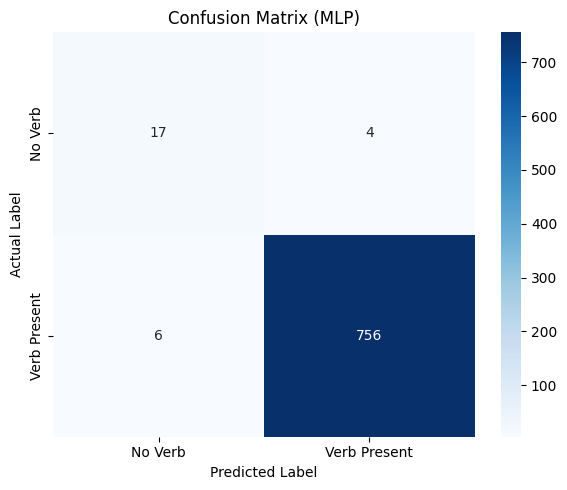

In [9]:
# In cell 6

import matplotlib.pyplot as plt
import seaborn as sns


# Plot Confusion Matrix for MLP
plt.figure(figsize=(6, 5)) # Adjusted figure size for single plot

sns.heatmap(conf_matrix_mlp, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Verb', 'Verb Present'],
            yticklabels=['No Verb', 'Verb Present'])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix (MLP)")

# Removed subplot structure and Balanced Random Forest plot

plt.tight_layout()
plt.show()